In [69]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [121]:
tss_enrich = read.table(
    file = '/private/groups/brookslab/gabai/projects/yeastMeth/data/ref/sacCer3_ares_v13_flairome_TSS_enrichment.tsv', 
    header = T, 
    sep = '\t') %>% select(-positions)

mature_rna_de<- read.table("../data/7_mature_rna_joint_isoform_DE_vs_gene_de_by_expr.tsv", sep = "\t", header = T, row.names = 1)
tss_enrich<- tss_enrich %>% filter(gene %in% rownames(mature_rna_de))
dim(tss_enrich)
dim(mature_rna_de)

tss_enrich<- cbind(tss_enrich,mature_rna_de[tss_enrich$gene, ])
tss_enrich<- tss_enrich %>% 
                    mutate(class  = factor(class, levels = c("low", "medium", "high")),
                           downstream = factor(downstream, levels = c("Down in MUT", "Up in MUT", "Not sig")))



tata_enrich = read.table(
    file = '/private/groups/brookslab/gabai/projects/yeastMeth/data/ref/sacCer3_ares_v13_flairome_TATA_enrichment.tsv', 
    header = T, 
    sep = '\t') %>% select(-positions)

mature_rna_de<- read.table("../data/7_mature_rna_joint_isoform_DE_vs_gene_de_by_expr.tsv", sep = "\t", header = T, row.names = 1)
tata_enrich<- tata_enrich %>% filter(gene %in% rownames(mature_rna_de))
dim(tata_enrich)
dim(mature_rna_de)

tata_enrich<- cbind(tata_enrich,mature_rna_de[tata_enrich$gene, ])
tata_enrich<- tata_enrich %>% 
                    mutate(class  = factor(class, levels = c("low", "medium", "high")),
                           downstream = factor(downstream, levels = c("Down in MUT", "Up in MUT", "Not sig")))

[1] 4655    8

[1] 4655   13

[1] 4655    8

[1] 4655   13

Joining with `by = join_by(class)`


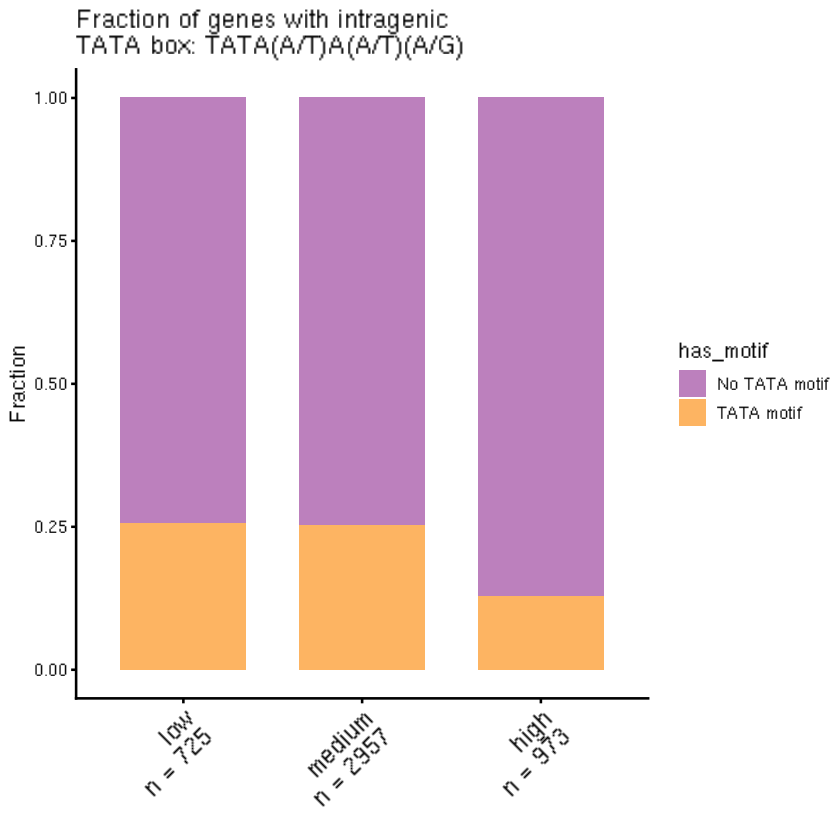

In [143]:
df<- tata_enrich %>% mutate(has_motif = if_else(observed > 0, 'TATA motif', 'No TATA motif')) %>% select(class, downstream, has_motif)
df2<- count(df, class, name = 'total')

df<- df %>% count(class, has_motif) %>% left_join(df2) %>% mutate(frac = n/total)

x_label<- paste0(df2$class, "\nn = ", df2$total)
names(x_label)<- df2$class

mcol <- c("#fdb462", "#bc80bd")
names(mcol) <- c("TATA motif", "No TATA motif")

df %>% 
    ggplot(aes(x = class, y = frac, fill = has_motif)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    labs(x = '', y = 'Fraction', title = 'Fraction of genes with intragenic\nTATA box: TATA(A/T)A(A/T)(A/G)') +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 14)) +
    scale_x_discrete(labels = x_label) +
    scale_fill_manual(values = mcol)

ggsave('../figures/Supp_TATA_genes_by_expression.pdf', width = 4, height = 3)

Joining with `by = join_by(class)`


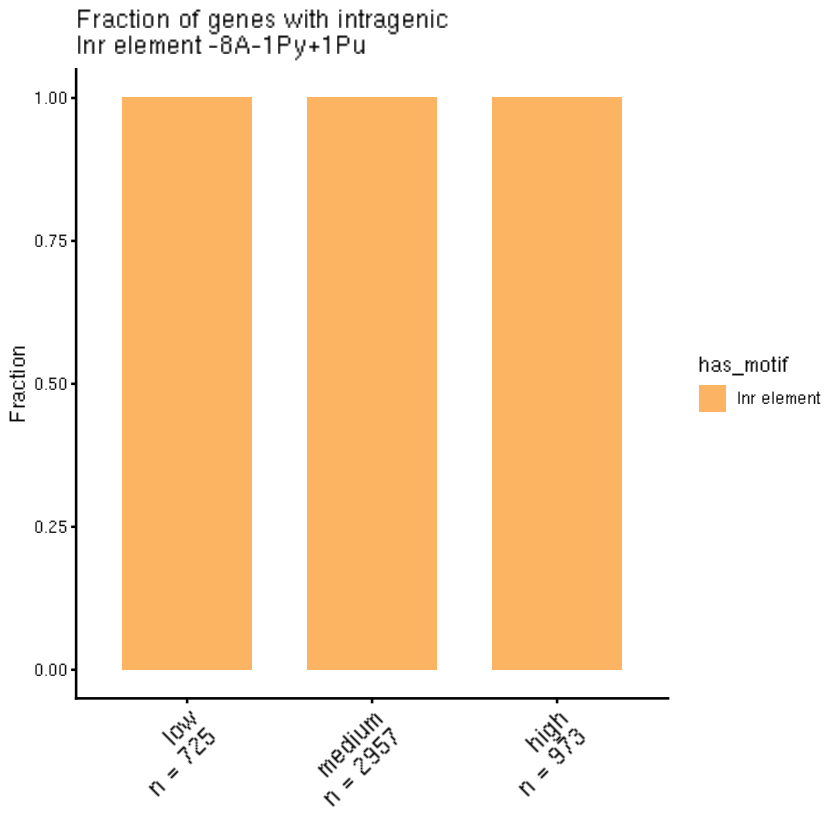

In [142]:
df<- tss_enrich %>% mutate(has_motif = if_else(observed > 0, 'Inr element', 'No Inr element')) %>% select(class, downstream, has_motif)
df2<- count(df, class, name = 'total')

df<- df %>% count(class, has_motif) %>% left_join(df2) %>% mutate(frac = n/total)

x_label<- paste0(df2$class, "\nn = ", df2$total)
names(x_label)<- df2$class

mcol <- c("#fdb462", "#bc80bd")
names(mcol) <- c('Inr element', 'No Inr element')

df %>% 
    ggplot(aes(x = class, y = frac, fill = has_motif)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    labs(x = '', y = 'Fraction', title = 'Fraction of genes with intragenic\nInr element: -8A-1Py+1Pu') +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 14)) +
    scale_x_discrete(labels = x_label) +
    scale_fill_manual(values = mcol)

ggsave('../figures/Supp_Inr_genes_by_expression.pdf', width = 4, height = 3)